In [17]:
import gymnasium as gym
import numpy as np
from envs.register import register_envs
register_envs()

from explorers import EpsilonGreedy
from learners import Qlearning, QuantileRegression
from dist_run import *
from policy_util import *
from analysis import *
from matplotlib import pyplot as plt

def get_tau(N): return (np.arange(N) + 0.5) / N

params = Params(
    model_name="WindyRooms-v1",
    total_episodes=10_000,
    save_skip=10,
    n_runs=1,
    seed=123,
    
    lr_decay=2000,
    learning_rate=0.4,

    gamma=0.99,
    epsilon=0.1,
    huber_k=0.0,
    n_quantiles=128,
    
    action_size=None,
    state_size=None,
    map_size=None,
    
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = get_tau(params.n_quantiles)

env = gym.make(
    params.model_name,
    render_mode="rgb_array",
    # p_random=0.25
    # desc=None,
    # reward_schedule=(10, -100, -1),
    # success_rate=0.75,
)
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)

env.reset()
s_init = env.unwrapped.s

learner = QuantileRegression(params)
if isinstance(learner, Qlearning): params = params._replace(n_quantiles=1)
if params.learner_name is None:
    params = params._replace(learner_name=str(learner).split(".")[1].split(" ")[0])

In [19]:
# tables, qtables, params = load_experiment()
# V_q = qtables.max(-1)

In [18]:
policy, V = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(params.epsilon, rng, policy=policy)

tables_run = run_env(env, learner, explorer, params)
tables = tables_run.mean(0)
qtables = tables.mean(-1)
V_q = qtables.max(-1)

# save_experiment(tables, params)

Run 0/1 - Episodes: 100%|██████████| 10000/10000 [00:22<00:00, 444.06it/s]


In [4]:
returns = MonteCarlo(env, policy, params, s_init, rng, epsilon=0.0, total_episodes=100_000)

100%|██████████| 100000/100000 [00:37<00:00, 2674.07it/s]


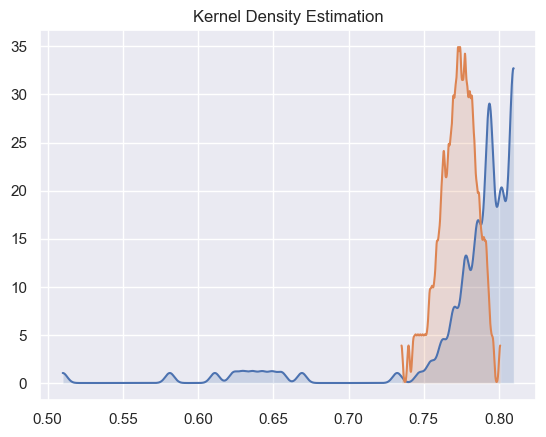

In [33]:
plot_returns(np.quantile(returns, tau), bandwidth=0.003)
plot_returns(tables[-1,s_init,1], bandwidth=0.0008)

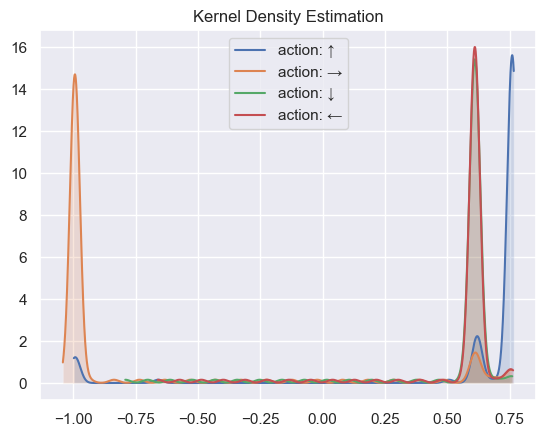

In [5]:
plot_kde(tables[-1, s_init], params, bandwidth=0.02)

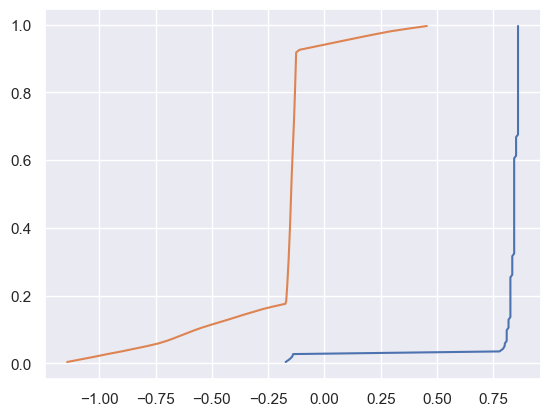

In [186]:
plt.plot(np.quantile(returns, tau), tau)
plt.plot(tables[-1, s_init, 1], tau)

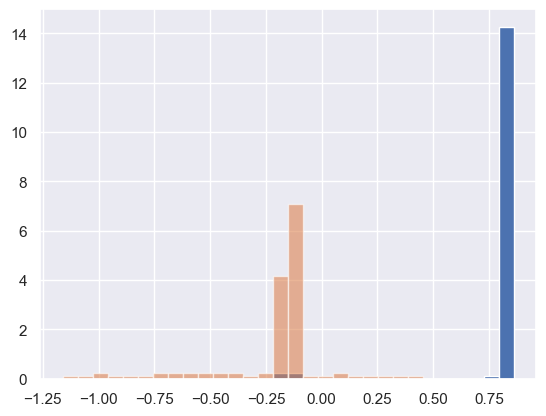

In [ ]:
_, bins, _ = plt.hist(returns, bins=30, density=True)
plt.hist(tables[-1, s_init,1], bins=bins, density=True, alpha=0.6);

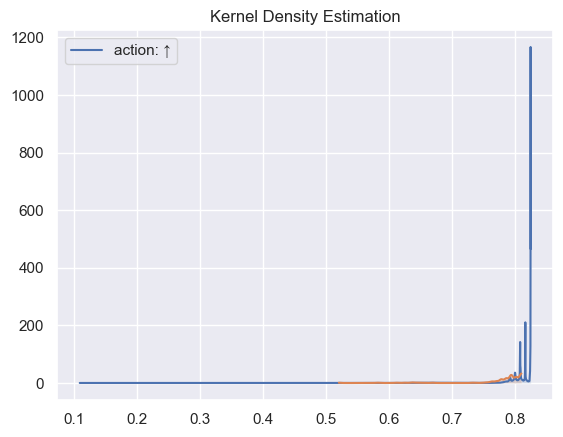

In [149]:
# returns = MonteCarlo(env, policy, params, s_init, rng, epsilon=0.0, total_episodes=2_000)

plot_grad(tables[-1, s_init, 1:2], params)
plot_returns(np.quantile(np.sort(returns), tau), bandwidth=0.003)

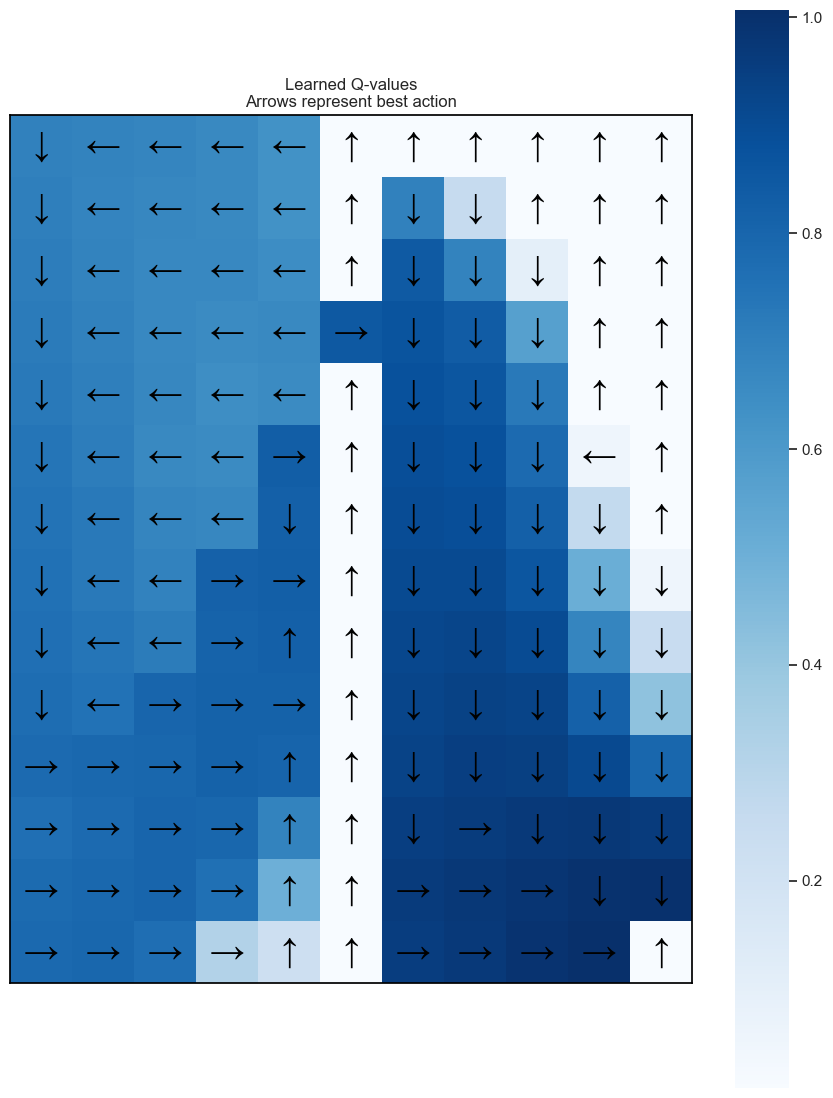

In [37]:
plot_optimal_action(qtables[-1], params)

In [63]:
0.99**21

0.8097278682212584

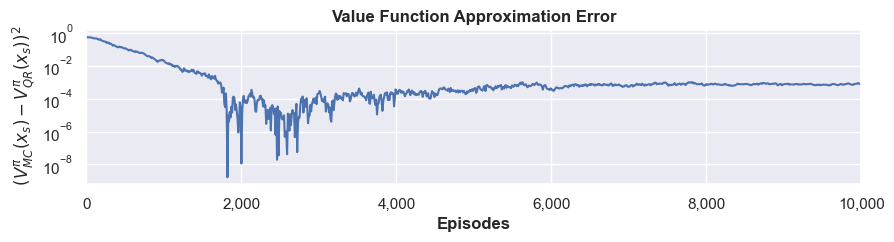

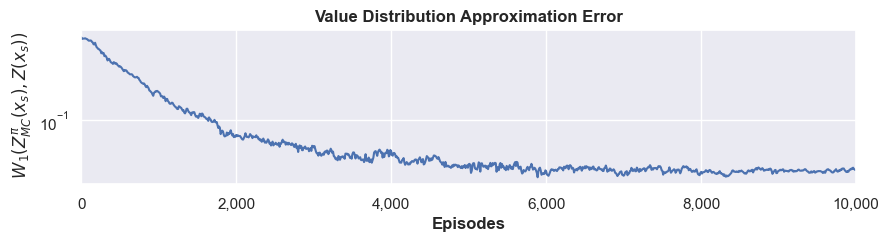

In [43]:
V_mc = returns.mean()
V_qr = qtables[:,s_init].max(-1)

fig, ax = plot_value_approx((V_mc - V_qr)**2, params)
ax.set_ylabel(" $ (V_{MC}^{\pi}(x_s) - V_{QR}^{\pi}(x_s) )^2 $");
ax.set_xlabel("Episodes", fontweight="bold")
ax.set_title("Value Function Approximation Error", fontweight="bold")

Z_mc = np.quantile(np.sort(returns), tau)
Z_qr = tables[:, s_init].max(1)

fig, ax = plot_value_approx(abs(Z_qr - Z_mc).mean(1), params)